# Tarea 08 - Clustering
Ejecución de los 3 ejemplos vistos en clase (K-Means, Hierarchical, DBSCAN) y respuesta a las preguntas conceptuales.

In [13]:
%matplotlib inline

## 1. K-Means

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [15]:
# Crear un conjunto de datos sintético con 4 centros
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Convertir el conjunto de datos en un DataFrame de Pandas
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

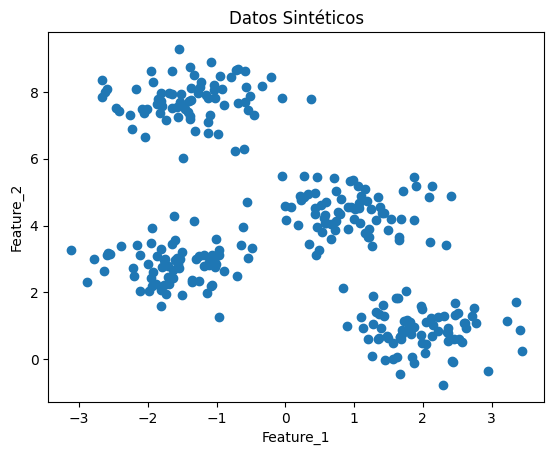

In [16]:
plt.scatter(df['Feature_1'], df['Feature_2'])
plt.title("Datos Sintéticos")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.show()

**📸 SCREENSHOT #1:** datos sintéticos originales (sin clusterizar).

In [17]:
# Crear el modelo k-means con 4 clusters
kmeans = KMeans(n_clusters=4)

# Ajustar el modelo a los datos
kmeans.fit(df)
# Obtener los centroides y las etiquetas de los clusters
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

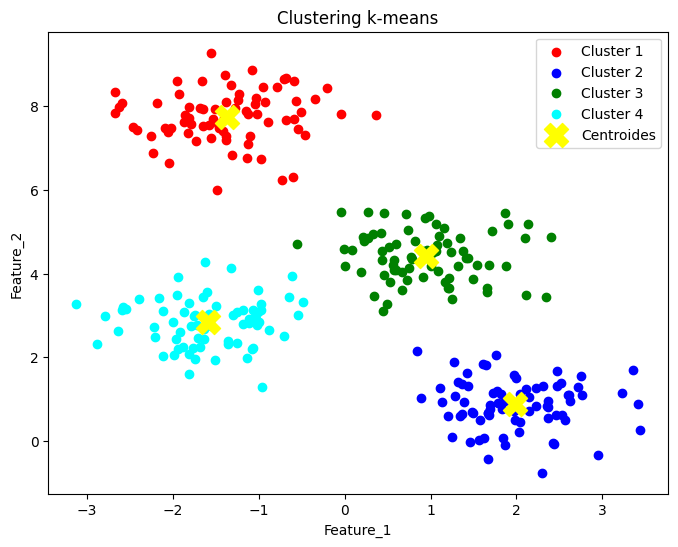

In [18]:
# Crear una figura
plt.figure(figsize=(8, 6))

# Colores para los clusters
colors = ['red', 'blue', 'green', 'cyan']

# Graficar los puntos coloreados por sus etiquetas
for i in range(4):
    plt.scatter(df['Feature_1'][labels == i], df['Feature_2'][labels == i],
                c=colors[i], label=f'Cluster {i+1}')

# Graficar los centroides
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='yellow', label='Centroides', marker='X')

plt.title("Clustering k-means")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.legend()
plt.show()

**📸 SCREENSHOT #2:** resultado del clustering K-Means (4 clusters de colores + centroides marcados con X amarilla).

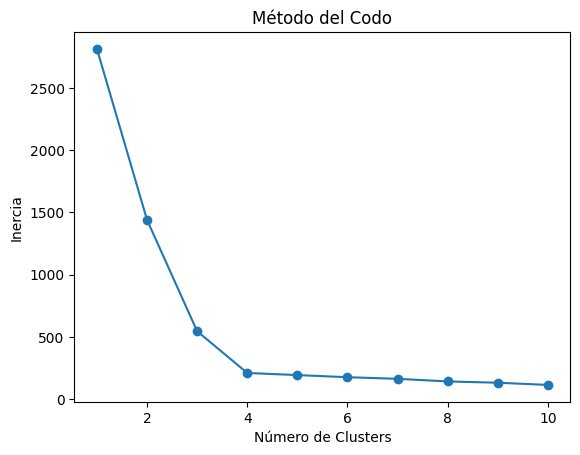

In [19]:
from sklearn.metrics import silhouette_score

# Método del codo
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

**📸 SCREENSHOT #3:** gráfica del método del codo (para elegir el número óptimo de clusters).

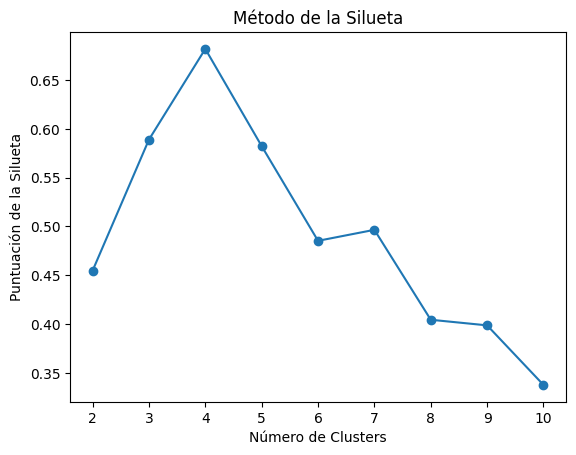

In [20]:
# Método de la Silueta
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Puntuación de la Silueta')
plt.title('Método de la Silueta')
plt.show()

**📸 SCREENSHOT #4:** gráfica del método de la silueta.

## 2. Clustering Jerárquico (Hierarchical)

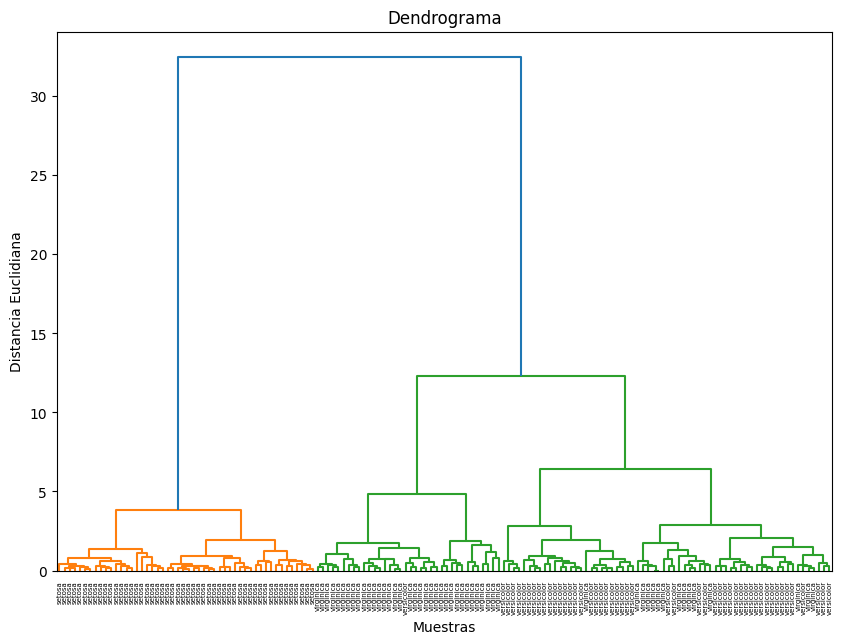

In [21]:
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Cargar conjunto de datos de ejemplo
data = load_iris()
X = data.data

# Aplicar clustering jerárquico
linked = sch.linkage(X, method='ward')

# Dibujar el dendrograma
plt.figure(figsize=(10, 7))
sch.dendrogram(linked, labels=data.target_names[data.target])
plt.title('Dendrograma')
plt.xlabel('Muestras')
plt.ylabel('Distancia Euclidiana')
plt.show()

**📸 SCREENSHOT #5:** dendrograma con el método `ward` (dataset Iris).

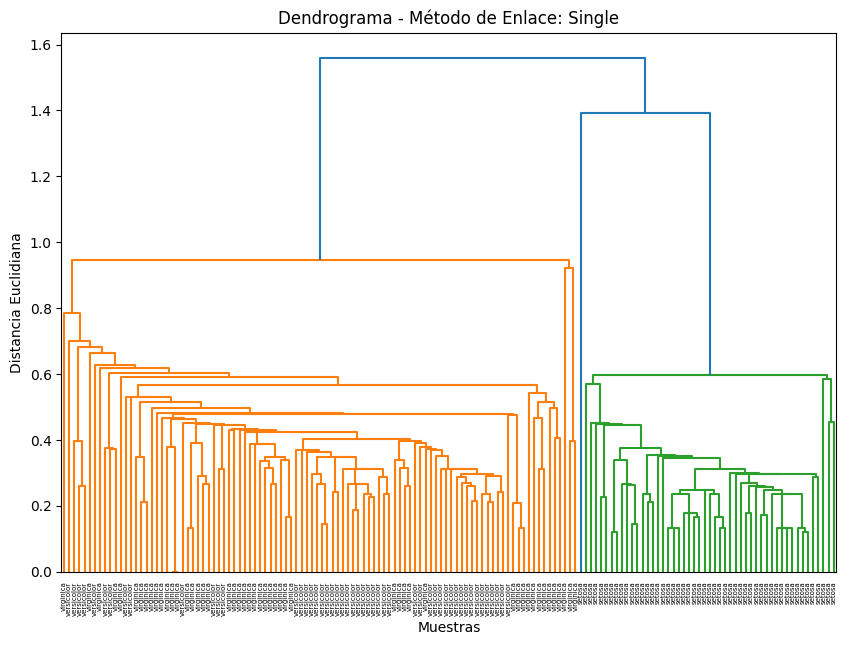

Método de Enlace: Single - Puntuación de la Silueta: 0.505


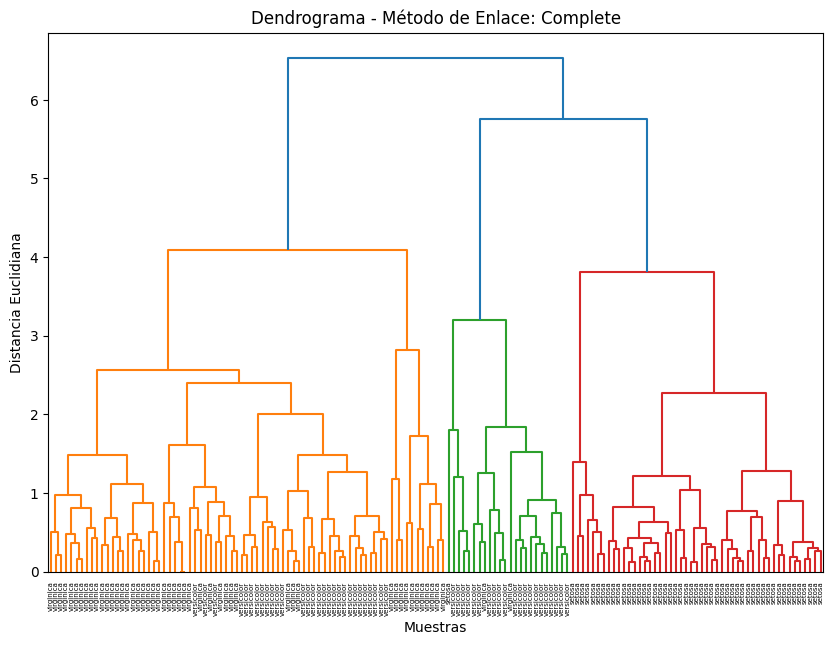

Método de Enlace: Complete - Puntuación de la Silueta: 0.450


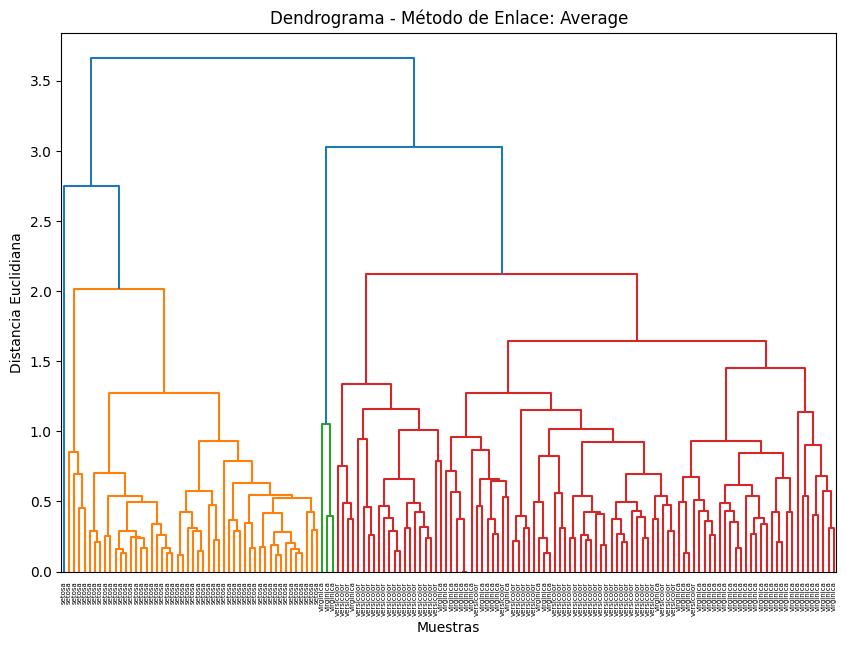

Método de Enlace: Average - Puntuación de la Silueta: 0.480


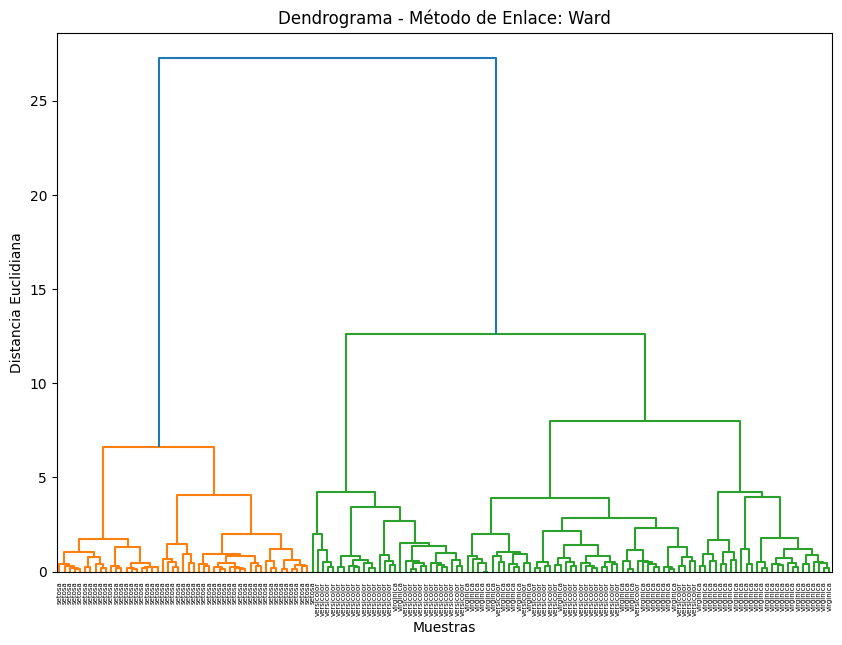

Método de Enlace: Ward - Puntuación de la Silueta: 0.447


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar clustering jerárquico con diferentes métodos de enlace
methods = ['single', 'complete', 'average', 'ward']
for method in methods:
    linked = sch.linkage(X_scaled, method=method)
    plt.figure(figsize=(10, 7))
    sch.dendrogram(linked, labels=data.target_names[data.target])
    plt.title(f'Dendrograma - Método de Enlace: {method.capitalize()}')
    plt.xlabel('Muestras')
    plt.ylabel('Distancia Euclidiana')
    plt.show()

    # Obtener clusters usando el método de enlace
    clusters = sch.fcluster(linked, t=3, criterion='maxclust')
    score = silhouette_score(X_scaled, clusters)
    print(f'Método de Enlace: {method.capitalize()} - Puntuación de la Silueta: {score:.3f}')

**📸 SCREENSHOT #6:** los 4 dendrogramas generados (single, complete, average, ward) junto con las 4 líneas impresas de "Puntuación de la Silueta" que aparecen debajo de cada gráfica (puedes tomar una sola captura larga que incluya el texto con los 4 scores, o una por método si tu profesor lo pide desglosado).

## 3. DBSCAN

**Nota:** el notebook original de clase tenía un error — faltaba `import numpy as np`, por lo que fallaba en la línea `np.sort(...)`. Aquí ya está corregido.

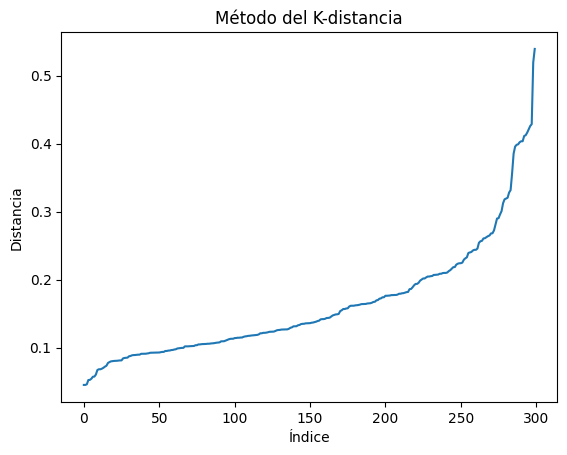

In [23]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

# Datos de ejemplo
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
X_scaled = StandardScaler().fit_transform(X)

# Calcular distancias k-vecinas más cercanas
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Distancia de la k-ésima vecindad más cercana
distances = np.sort(distances[:, 4], axis=0)

plt.plot(distances)
plt.title('Método del K-distancia')
plt.xlabel('Índice')
plt.ylabel('Distancia')
plt.show()

**📸 SCREENSHOT #7:** gráfica del método K-distancia (sirve para elegir el parámetro `eps` de DBSCAN, en el 'codo' de la curva).

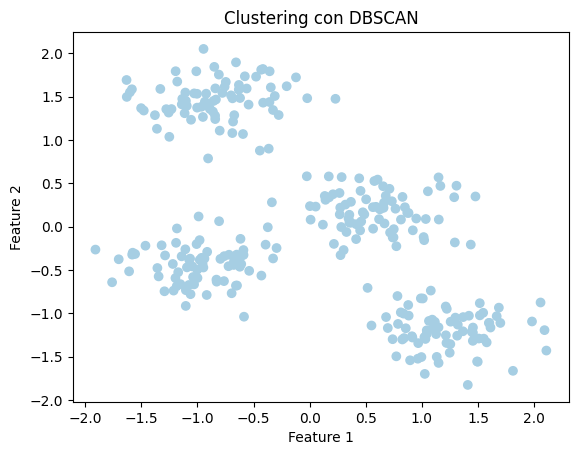

In [24]:
# Aplicar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=2)
clusters = dbscan.fit_predict(X_scaled)

# Visualización
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='Paired', marker='o')
plt.title('Clustering con DBSCAN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**📸 SCREENSHOT #8:** resultado final del clustering con DBSCAN (colores = clusters encontrados; los puntos etiquetados como ruido, si los hay, aparecen con la etiqueta -1).

## 4. Preguntas conceptuales

### ¿Qué es el problema de la "maldición de la dimensionalidad"?

La maldición de la dimensionalidad (*curse of dimensionality*) se refiere al conjunto de problemas que surgen cuando se trabaja con datos que tienen un número muy grande de variables o dimensiones. A medida que aumenta el número de dimensiones, el volumen del espacio crece exponencialmente, por lo que los datos se vuelven cada vez más dispersos (*sparse*) dentro de ese espacio. Esto trae varias consecuencias negativas para el clustering:

- **Las nociones de distancia y densidad pierden significado:** en dimensiones altas, la distancia entre el punto más cercano y el más lejano a un punto de referencia tiende a volverse casi igual, por lo que algoritmos que dependen de distancias (como K-Means) o de densidad (como DBSCAN) tienen más dificultad para distinguir puntos cercanos de puntos lejanos.
- **Se requieren muchos más datos:** para mantener la misma densidad de muestras por unidad de volumen, la cantidad de observaciones necesarias crece exponencialmente con el número de dimensiones.
- **Aumenta el costo computacional** y el riesgo de sobreajuste, ya que los modelos tienen más parámetros o más variables irrelevantes de las cuales "aprender" ruido.

En los ejemplos de esta tarea esto se puede ilustrar con el caso de **DBSCAN**: el algoritmo depende directamente del parámetro `eps`, que se calcula a partir de distancias entre vecinos (celda del método K-distancia). En un espacio de solo 2 dimensiones (como el usado en el ejemplo, `Feature_1` y `Feature_2`) esta distancia es fácil de interpretar visualmente y el "codo" de la curva se distingue con claridad; sin embargo, si el número de variables (dimensiones) creciera mucho, esa distancia dejaría de ser un buen indicador para separar clusters de ruido, lo cual es precisamente el efecto de la maldición de la dimensionalidad.

### ¿Qué es el PCA y para qué se utiliza en clustering?

El **Análisis de Componentes Principales (PCA, por sus siglas en inglés)** es una técnica de reducción de dimensionalidad que transforma un conjunto de variables (posiblemente correlacionadas) en un nuevo conjunto de variables no correlacionadas llamadas **componentes principales**. Estos componentes se ordenan de manera que el primero capture la mayor cantidad posible de la varianza de los datos originales, el segundo la mayor varianza restante (siendo ortogonal al primero), y así sucesivamente.

En el contexto de clustering, el PCA se utiliza principalmente para:

1. **Mitigar la maldición de la dimensionalidad:** al reducir el número de variables (por ejemplo, quedarse solo con los 2 o 3 componentes principales que explican la mayor parte de la varianza), las medidas de distancia y densidad vuelven a ser significativas, mejorando el desempeño de algoritmos como K-Means, Hierarchical o DBSCAN.
2. **Visualización:** cuando el conjunto de datos original tiene más de 2 o 3 variables, es imposible graficarlo directamente. Aplicando PCA se pueden proyectar los datos a 2D o 3D para poder visualizar los clusters resultantes, tal como se hizo en el ejemplo de **Hierarchical**, donde el dataset Iris tiene 4 variables (`sepal length`, `sepal width`, `petal length`, `petal width`) — en un caso real, antes de graficar el dendrograma o los clusters en un plano, normalmente se aplicaría PCA para reducir esas 4 dimensiones a 2 y poder interpretar visualmente los resultados.
3. **Eliminar ruido y redundancia:** al descartar los componentes con menor varianza (que suelen capturar ruido o información redundante entre variables correlacionadas), el algoritmo de clustering trabaja sobre una representación más limpia y compacta de los datos, lo que generalmente mejora tanto la velocidad de cómputo como la calidad de los clusters encontrados.

En resumen, el PCA no es un algoritmo de clustering en sí mismo, sino un **paso de preprocesamiento** que casi siempre se recomienda cuando el número de variables es alto, precisamente para contrarrestar los efectos negativos descritos en la pregunta anterior.
